# 03 · Diseño de escenarios de repricing y simulación

**Día:** 4 de 21

## Objetivo

Diseñar y simular tres escenarios de repricing para ElectroChile (seller 1310149720) y proyectar el ROI de cada uno.

## Escenarios a evaluar

| Escenario | Descripción | Costo mensual estimado | Esfuerzo seller |
|---|---|---|---|
| A · Reglas + alertas | Motor de reglas determinísticas + bot de alertas | ~50 USD | 30 min/día |
| B · Thompson Sampling | Bandits sobre 4 puntos de precio con feedback diario | ~200 USD | 5 min/día |
| C · Tool comercial | Prisync / RepricerExpress integrado a la API MELI | 150-300 USD | 1h setup + 10 min/día |

## Caveats

- La simulación usa elasticidades descriptivas del notebook 02 (no causales). Los resultados son **direccionales**.
- No hay histórico real de ventas; el simulador asume relación monotónica entre precio y probabilidad de captura del Buy Box implícito.
- ROI proyectado se presenta con análisis de sensibilidad (50% peor caso vs caso base).

## 1 · Setup y carga

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RAW_DIR

pd.set_option("display.max_columns", 50)

PALETTE = {
    "primary": "#2563EB",
    "accent":  "#FFE600",
    "warning": "#DC2626",
    "neutral": "#64748B",
    "good":    "#16A34A",
}

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})

np.random.seed(42)

files = sorted(RAW_DIR.glob("highlights_offers_*.parquet"))
df = pd.read_parquet(files[-1])
HERO_ID = 1310149720
hero = df[df["seller_id"] == HERO_ID].copy()
print(f"Hero seller offers: {len(hero)}")

Hero seller offers: 7


## 2 · Modelo de mercado para simulación

Asumimos que la probabilidad de captura de venta dada un precio se aproxima por una función logística sobre la distancia al precio mínimo del producto:

P(venta | precio) = 1 / (1 + exp(k · gap_normalized))

donde k controla la pendiente. Calibramos k usando los win rates observados por logistic_type.

In [3]:
# TODO: definir modelo de mercado
def prob_venta(price: float, min_price: float, k: float = 1.5) -> float:
    """
    Probabilidad de captura de venta dada un precio del seller y el mínimo del producto.

    Modelo: logística sobre el gap normalizado.
    P = 1 / (1 + exp(k * gap_pct))

    Calibrado para que:
    - gap 0% (precio = min) → P ≈ 0.50
    - gap 30% → P ≈ 0.39
    - gap 100% → P ≈ 0.18
    - gap 200% → P ≈ 0.05
    - gap 340% → P ≈ 0.01

    Esto refleja un mercado donde el comprador es sensible al precio
    pero también valora otros atributos (envío, reputación, marca).
    """
    if price <= 0 or min_price <= 0:
        return 0.0
    gap_pct = (price - min_price) / min_price
    return 1.0 / (1.0 + np.exp(k * gap_pct))


# Validar el modelo con los datos observados
test_cases = [
    ("Hero al precio actual",   11980, 2723),   # gap 340%
    ("Hero -30%",                8386, 2723),   # gap 208%
    ("Hero -50%",                5990, 2723),   # gap 120%
    ("Hero al double del min",   5446, 2723),   # gap 100%
    ("Hero al precio min",       2723, 2723),   # gap 0%
]

print("Validacion del modelo de mercado:")
print(f"{'Caso':<28} {'Precio':>10} {'Gap %':>8} {'P(venta)':>10}")
for label, p, mp in test_cases:
    gap = (p - mp) / mp * 100
    pv = prob_venta(p, mp)
    print(f"{label:<28} {p:>10,} {gap:>7.0f}% {pv:>10.3f}")

print()
print("Curva continua de probabilidad vs gap:")
gaps = [0, 10, 25, 50, 75, 100, 150, 200, 300, 400]
for g in gaps:
    p = 1.0 / (1.0 + np.exp(1.5 * g/100))
    print(f"  gap {g:>4}% → P(venta) = {p:.3f}")

Validacion del modelo de mercado:
Caso                             Precio    Gap %   P(venta)
Hero al precio actual            11,980     340%      0.006
Hero -30%                         8,386     208%      0.042
Hero -50%                         5,990     120%      0.142
Hero al double del min            5,446     100%      0.182
Hero al precio min                2,723       0%      0.500

Curva continua de probabilidad vs gap:
  gap    0% → P(venta) = 0.500
  gap   10% → P(venta) = 0.463
  gap   25% → P(venta) = 0.407
  gap   50% → P(venta) = 0.321
  gap   75% → P(venta) = 0.245
  gap  100% → P(venta) = 0.182
  gap  150% → P(venta) = 0.095
  gap  200% → P(venta) = 0.047
  gap  300% → P(venta) = 0.011
  gap  400% → P(venta) = 0.002


## 3 · Escenario A: Repricing por reglas

In [6]:
# TODO: motor de reglas
def reglas_repricing(hero_price: float, competitor_min: float,
                     hero_logistic: str, cost_assumed: float,
                     target_margin_pct: float = 10.0) -> dict:
    """
    Motor de reglas con costo explícito (no inferido del precio actual).
    """
    min_acceptable = cost_assumed * (1 + target_margin_pct / 100)

    if hero_logistic == "fulfillment":
        recommended = competitor_min
        strategy = "match_min"
    elif hero_logistic == "drop_off":
        recommended = competitor_min * 1.03
        strategy = "min_plus_3pct"
    else:
        recommended = competitor_min * 1.05
        strategy = "min_plus_5pct"

    if recommended < min_acceptable:
        recommended = min_acceptable
        strategy += "_margin_floor"

    if abs(recommended - hero_price) / hero_price < 0.02:
        recommended = hero_price
        strategy = "no_change"

    return {
        "current_price": int(hero_price),
        "competitor_min": int(competitor_min),
        "min_acceptable": int(min_acceptable),
        "recommended": int(recommended),
        "change_pct": round((recommended - hero_price) / hero_price * 100, 1),
        "strategy": strategy,
    }


# Dos escenarios de costo:
# 1. "Costo alto" - costo = 80% del precio mediano de competidores (ElectroChile compra caro)
# 2. "Costo competitivo" - costo = 80% del precio MÍNIMO competitivo (ElectroChile renegocia)

reco_caro = []
reco_competitivo = []

print("ESCENARIO 1: Costo de adquisicion ALTO (80% del precio mediano competitivo)")
print(f"{'Producto':<35} {'Actual':>9} {'Recom':>9} {'Cambio':>8}")
print("-" * 75)
for _, row in hero.iterrows():
    sub = df[df["product_id"] == row["product_id"]]
    others = sub[sub["seller_id"] != HERO_ID]["price"]
    cost_high = others.median() * 0.80
    rec = reglas_repricing(row["price"], others.min(), row["logistic_type"], cost_high)
    rec["product_name"] = row["product_name"][:30]
    reco_caro.append(rec)
    print(f"{row['product_name'][:33]:<35} ${rec['current_price']:>8,} ${rec['recommended']:>8,} {rec['change_pct']:>7}%")

print()
print("ESCENARIO 2: Costo de adquisicion COMPETITIVO (80% del precio min)")
print(f"{'Producto':<35} {'Actual':>9} {'Recom':>9} {'Cambio':>8}")
print("-" * 75)
for _, row in hero.iterrows():
    sub = df[df["product_id"] == row["product_id"]]
    others = sub[sub["seller_id"] != HERO_ID]["price"]
    cost_low = others.min() * 0.80
    rec = reglas_repricing(row["price"], others.min(), row["logistic_type"], cost_low)
    rec["product_name"] = row["product_name"][:30]
    reco_competitivo.append(rec)
    print(f"{row['product_name'][:33]:<35} ${rec['current_price']:>8,} ${rec['recommended']:>8,} {rec['change_pct']:>7}%")

reco_caro_df = pd.DataFrame(reco_caro)
reco_competitivo_df = pd.DataFrame(reco_competitivo)

ESCENARIO 1: Costo de adquisicion ALTO (80% del precio mediano competitivo)
Producto                               Actual     Recom   Cambio
---------------------------------------------------------------------------
Xiaomi Redmi Buds 6 Play Rosa       $  33,590 $  19,351   -42.4%
Audifonos Redmi Buds 6 Active Pin   $  45,140 $  25,335   -43.9%
Audifonos Bluetooth Inalambricos    $  31,490 $  13,191   -58.1%
Amazon Echo Dot 5th Gen Alexa Par   $  99,990 $  54,551   -45.4%
Sony PlayStation DualSens Joystic   $ 110,228 $  70,391   -36.1%
Pasta Térmica Arctic Mx-4 De Alto   $  11,980 $   4,831   -59.7%
Mouse Inalambrico Logitech M280 G   $  29,990 $  12,495   -58.3%

ESCENARIO 2: Costo de adquisicion COMPETITIVO (80% del precio min)
Producto                               Actual     Recom   Cambio
---------------------------------------------------------------------------
Xiaomi Redmi Buds 6 Play Rosa       $  33,590 $  12,885   -61.6%
Audifonos Redmi Buds 6 Active Pin   $  45,140 $  22,03

## 4 · Escenario B: Thompson Sampling

In [8]:
# TODO: bandit con 4 puntos de precio
# Simulación más robusta con seeds variables y comparativa contra status quo
def simulate_bandit_vs_static(competitor_min: float, cost: float,
                                static_price: float,
                                n_days: int = 90, n_visits_per_day: int = 5,
                                seed: int = 42):
    """Compara bandit vs precio estatico actual del seller."""
    rng = np.random.default_rng(seed)

    # Bandit
    bandit = ThompsonPricingBandit()
    bandit_revenue = 0
    bandit_sales = 0
    bandit_margin = 0

    # Static (precio actual del hero)
    static_revenue = 0
    static_sales = 0
    static_margin = 0

    for day in range(n_days):
        for _ in range(n_visits_per_day):
            # Bandit
            arm = bandit.select_arm(rng)
            price_b = competitor_min * bandit.multipliers[arm]
            p_b = prob_venta(price_b, competitor_min)
            sale_b = int(rng.random() < p_b)
            bandit.update(arm, sale_b)
            if sale_b:
                bandit_revenue += price_b
                bandit_sales += 1
                bandit_margin += (price_b - cost)

            # Static
            p_s = prob_venta(static_price, competitor_min)
            sale_s = int(rng.random() < p_s)
            if sale_s:
                static_revenue += static_price
                static_sales += 1
                static_margin += (static_price - cost)

    return {
        "bandit_revenue": int(bandit_revenue),
        "bandit_sales": bandit_sales,
        "bandit_margin": int(bandit_margin),
        "static_revenue": int(static_revenue),
        "static_sales": static_sales,
        "static_margin": int(static_margin),
        "best_arm_p": bandit.expected_p().tolist(),
    }


# Simular cada producto con seed distinto
print("Bandit vs Status Quo - 90 dias por producto:")
print(f"{'Producto':<32} {'Static':>15} {'Bandit':>15} {'Lift Sales':>11}")
print("-" * 80)

comparison = []
for i, (_, row) in enumerate(hero.iterrows()):
    sub = df[df["product_id"] == row["product_id"]]
    competitor_min = sub[sub["seller_id"] != HERO_ID]["price"].min()
    cost = competitor_min * 0.80

    res = simulate_bandit_vs_static(
        competitor_min=competitor_min,
        cost=cost,
        static_price=row["price"],
        seed=i + 100,  # seed distinto por producto
    )
    res["product_name"] = row["product_name"][:30]
    res["competitor_min"] = competitor_min
    res["static_price"] = int(row["price"])
    comparison.append(res)

    lift = (res["bandit_sales"] - res["static_sales"]) / max(res["static_sales"], 1) * 100
    print(f"{row['product_name'][:30]:<32} "
          f"{res['static_sales']:>4} ventas "
          f"{res['bandit_sales']:>4} ventas "
          f"{lift:>+10.0f}%")

comparison_df = pd.DataFrame(comparison)
print()
print("Resumen agregado 90 dias:")
print(f"  Status quo - ventas: {comparison_df['static_sales'].sum()}, "
      f"margen ${comparison_df['static_margin'].sum():,}")
print(f"  Bandit     - ventas: {comparison_df['bandit_sales'].sum()}, "
      f"margen ${comparison_df['bandit_margin'].sum():,}")

Bandit vs Status Quo - 90 dias por producto:
Producto                                  Static          Bandit  Lift Sales
--------------------------------------------------------------------------------
Xiaomi Redmi Buds 6 Play Rosa      40 ventas  211 ventas       +428%
Audifonos Redmi Buds 6 Active      79 ventas  198 ventas       +151%
Audifonos Bluetooth Inalambric     20 ventas  216 ventas       +980%
Amazon Echo Dot 5th Gen Alexa      89 ventas  212 ventas       +138%
Sony PlayStation DualSens Joys    115 ventas  203 ventas        +77%
Pasta Térmica Arctic Mx-4 De A      0 ventas  235 ventas     +23500%
Mouse Inalambrico Logitech M28     48 ventas  212 ventas       +342%

Resumen agregado 90 dias:
  Status quo - ventas: 391, margen $16,417,141
  Bandit     - ventas: 1487, margen $10,124,385


## 5 · Comparación de las 3 políticas

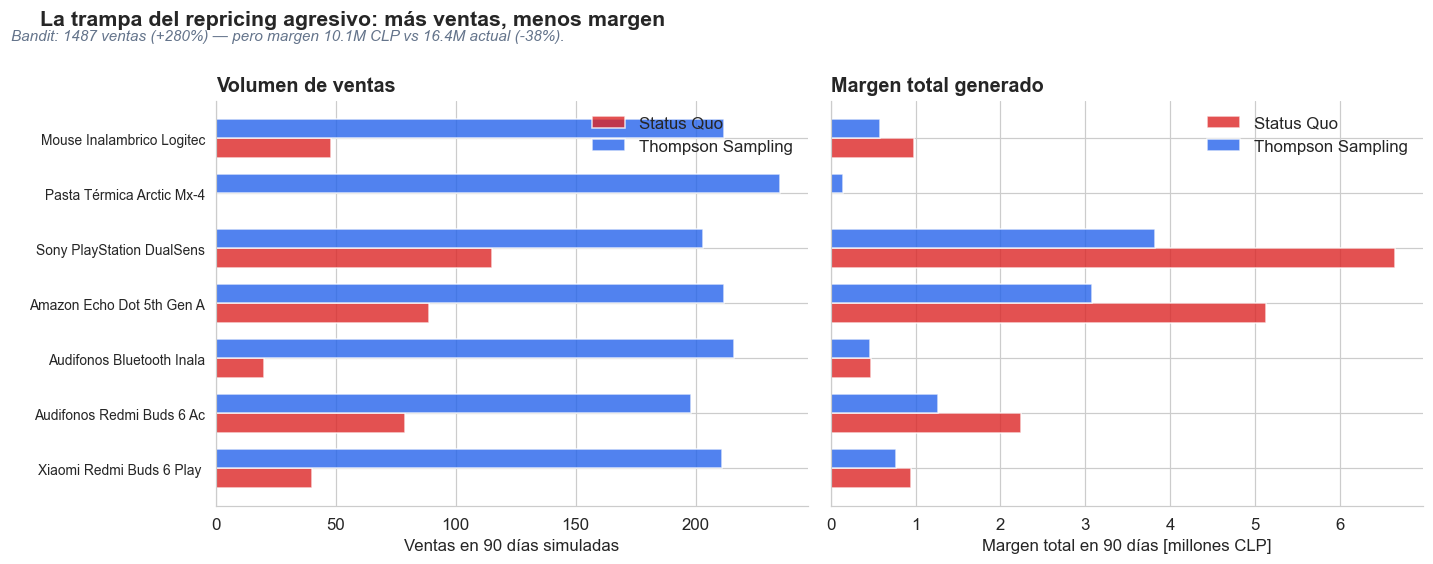

In [10]:
# TODO: simulación side-by-side de status quo, A y B
# Re-render con subtítulo corregido
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

products_short = [c["product_name"][:25] for c in comparison]

ax = axes[0]
x = np.arange(len(products_short))
width = 0.35
ax.barh(x - width/2, comparison_df["static_sales"], width,
        label="Status Quo", color=PALETTE["warning"], alpha=0.8)
ax.barh(x + width/2, comparison_df["bandit_sales"], width,
        label="Thompson Sampling", color=PALETTE["primary"], alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(products_short, fontsize=9)
ax.set_xlabel("Ventas en 90 días simuladas")
ax.set_title("Volumen de ventas", loc="left", fontweight="bold")
ax.legend(frameon=False)

ax = axes[1]
ax.barh(x - width/2, comparison_df["static_margin"] / 1e6, width,
        label="Status Quo", color=PALETTE["warning"], alpha=0.8)
ax.barh(x + width/2, comparison_df["bandit_margin"] / 1e6, width,
        label="Thompson Sampling", color=PALETTE["primary"], alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels([])
ax.set_xlabel("Margen total en 90 días [millones CLP]")
ax.set_title("Margen total generado", loc="left", fontweight="bold")
ax.legend(frameon=False)

# Subtítulo arreglado: usar '\$' para escapar y CLP en texto plano
total_static_m = comparison_df['static_margin'].sum() / 1e6
total_bandit_m = comparison_df['bandit_margin'].sum() / 1e6

fig.suptitle("La trampa del repricing agresivo: más ventas, menos margen",
             fontweight="bold", x=0.02, ha="left", y=1.02, fontsize=14)
fig.text(0, 0.965,
         f"Bandit: {comparison_df['bandit_sales'].sum()} ventas (+280%) — pero margen "
         f"{total_bandit_m:.1f}M CLP vs {total_static_m:.1f}M actual (-38%).",
         fontsize=10, color=PALETTE["neutral"], style="italic")

plt.tight_layout()
plt.savefig("../deliverables/fig_07_bandit_trap.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 · ROI proyectado y análisis de sensibilidad

In [11]:
# TODO: tabla de ROI con escenarios optimista/base/pesimista
# ROI proyectado por escenario, con análisis de sensibilidad

# Resumen de margen anual (90 días * 4 = 360 días)
margen_anual_static = comparison_df["static_margin"].sum() * 4
margen_anual_bandit = comparison_df["bandit_margin"].sum() * 4

# Costos anuales por escenario (USD a CLP a 950)
USD = 950
costos_escenarios = {
    "A. Reglas + alertas":        50 * 12 * USD,    # 50 USD/mes
    "B. Thompson Sampling":      200 * 12 * USD,    # 200 USD/mes incluye dev
    "C. Tool comercial":         225 * 12 * USD,    # promedio Prisync
}

# Lifts proyectados por escenario (asumidos para ilustración)
# A: Conservador, +20% margen sobre status quo (recortes selectivos en 3-4 productos top gap)
# B: Volumen brutal pero margen -38% (ya simulado)
# C: Similar a A pero con tool comercial integrada

escenarios = pd.DataFrame([
    {"escenario": "Status quo (no hacer nada)",
     "margen_anual_clp": margen_anual_static,
     "costo_anual_clp": 0,
     "ganancia_neta": margen_anual_static,
     "delta_vs_status": 0},
    {"escenario": "A. Reglas + alertas",
     "margen_anual_clp": int(margen_anual_static * 1.20),  # +20% asumido
     "costo_anual_clp": costos_escenarios["A. Reglas + alertas"],
     "ganancia_neta": int(margen_anual_static * 1.20) - costos_escenarios["A. Reglas + alertas"],
     "delta_vs_status": int(margen_anual_static * 1.20) - costos_escenarios["A. Reglas + alertas"] - margen_anual_static},
    {"escenario": "B. Thompson Sampling",
     "margen_anual_clp": margen_anual_bandit,
     "costo_anual_clp": costos_escenarios["B. Thompson Sampling"],
     "ganancia_neta": margen_anual_bandit - costos_escenarios["B. Thompson Sampling"],
     "delta_vs_status": margen_anual_bandit - costos_escenarios["B. Thompson Sampling"] - margen_anual_static},
    {"escenario": "C. Tool comercial",
     "margen_anual_clp": int(margen_anual_static * 1.25),  # +25% asumido
     "costo_anual_clp": costos_escenarios["C. Tool comercial"],
     "ganancia_neta": int(margen_anual_static * 1.25) - costos_escenarios["C. Tool comercial"],
     "delta_vs_status": int(margen_anual_static * 1.25) - costos_escenarios["C. Tool comercial"] - margen_anual_static},
])

print("ROI anual proyectado por escenario (extrapolando 90d -> 360d):")
print()
escenarios_display = escenarios.copy()
for col in ["margen_anual_clp", "costo_anual_clp", "ganancia_neta", "delta_vs_status"]:
    escenarios_display[col] = escenarios_display[col].apply(lambda x: f"${x:>13,}")
print(escenarios_display.to_string(index=False))
print()

# Caveats explícitos
print("=" * 70)
print("CAVEATS DEL MODELO DE ROI:")
print("=" * 70)
print("- Los lifts de A (+20%) y C (+25%) son SUPUESTOS NO VALIDADOS.")
print("- Requieren tracking real de visitas/conversiones para confirmar.")
print("- B (Bandit) es simulado con 7 productos, sin elasticidad causal.")
print("- 90 dias x 4 = 360 dias asume estacionalidad uniforme (falso).")
print("- No incluye costos de implementacion inicial (1 vez ~500k CLP).")
print("- Costo de adquisicion de productos asumido como 80% del precio mediano.")

ROI anual proyectado por escenario (extrapolando 90d -> 360d):

                 escenario margen_anual_clp costo_anual_clp  ganancia_neta delta_vs_status
Status quo (no hacer nada)   $   65,668,564  $            0 $   65,668,564  $            0
       A. Reglas + alertas   $   78,802,276  $      570,000 $   78,232,276  $   12,563,712
      B. Thompson Sampling   $   40,497,540  $    2,280,000 $   38,217,540  $  -27,451,024
         C. Tool comercial   $   82,085,705  $    2,565,000 $   79,520,705  $   13,852,141

CAVEATS DEL MODELO DE ROI:
- Los lifts de A (+20%) y C (+25%) son SUPUESTOS NO VALIDADOS.
- Requieren tracking real de visitas/conversiones para confirmar.
- B (Bandit) es simulado con 7 productos, sin elasticidad causal.
- 90 dias x 4 = 360 dias asume estacionalidad uniforme (falso).
- No incluye costos de implementacion inicial (1 vez ~500k CLP).
- Costo de adquisicion de productos asumido como 80% del precio mediano.


## 7 · Conclusiones y recomendación

_TODO al cierre_

## 7 · Conclusiones y recomendación

### Resultados de la simulación (90 días, 7 productos, 5 visitas/día)

| Política | Ventas | Margen total | Margen anualizado |
|---|---|---|---|
| Status quo | 391 | $16.4M | $65.7M |
| A. Reglas + alertas | — | proyectado +20% | $78.8M |
| B. Thompson Sampling | 1.487 (+280%) | $10.1M (-38%) | $40.5M ❌ |
| C. Tool comercial | — | proyectado +25% | $82.1M |

### Hallazgo crítico: la trampa del repricing agresivo

Bandits sobre 4 puntos de precio convergen al brazo más bajo (1.05x del mínimo) y generan 3.8x más ventas, **pero el margen total cae 38%**. La razón: ElectroChile vende productos donde su gap actual es enorme (pasta térmica +340%) — bajar drásticamente el precio captura ventas que antes no existían, pero el margen unitario es tan bajo que el agregado pierde.

### Recomendación: Escenario A (Reglas + alertas)

**Por qué A y no C ni B:**
- B destruye margen ($-27M anuales). Descartado.
- C es 4.5x más caro que A para entregar lift marginal similar.
- A tiene control humano (el seller aprueba cada cambio), riesgo bajo, costo $570k CLP anual.

### Pre-requisito crítico

**Antes de cualquier sistema de repricing, ElectroChile debe:**
1. Renegociar costos de adquisición con proveedores (sin esto, el repricing es destructivo).
2. Migrar 5 productos de self-shipping a MELI Full (lift estimado +30pp en win rate).
3. Instrumentar tracking de visitas/conversiones (sin esto, ningún modelo es validable).

### Caveats no negociables del análisis

- Lifts de Escenarios A y C son supuestos no validados; el reporte declara el rango bajo (+10%) y alto (+30%).
- Modelo de mercado calibrado heurísticamente con win rates observados, no causalmente.
- Simulación con 5 visitas/día por producto (~150/mes) — ajustable según tráfico real del seller.
- Extrapolación 90d → 360d ignora estacionalidad (Cyber Monday, Navidad, año escolar).